<a href="https://colab.research.google.com/github/rishike/llm_from_scratch/blob/main/entire_data_Preprocessing_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 : Creating tokens

In [2]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

In [3]:
raw_text[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [4]:
import re

text = "hello world. this, is a test."
result = re.split(r'(\s)', text)
print(result)

['hello', ' ', 'world.', ' ', 'this,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [5]:
result = re.split(r'([,.]|\s)', text)
print(result)

['hello', ' ', 'world', '.', '', ' ', 'this', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [6]:
text = "hello, world. is this-- a test?"

result = re.split(r'([,:;?!!"()\'.]|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['hello', ',', 'world', '.', 'is', 'this', '--', 'a', 'test', '?']


In [7]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [8]:
print(len(preprocessed))

4690


Step 2 : Creating Token IDs

In [9]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print(vocab_size)

1130


In [10]:
vocab = {token:integer for integer , token in enumerate((all_words))}

In [11]:
for i, item in enumerate(vocab.items()):
  print(item)
  if i >= 50:
    break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


In [12]:
class SimpleTokenizerV1:
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {i:s for s,i in vocab.items()}

  def encode(self, text):
    preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

    preprocessed = [
        item.strip() for item in preprocessed if item.strip()
    ]
    ids = [self.str_to_int[item] for item in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'([,.:;?_!"()\']|--|\s)', r'\1', text)
    return text

In [13]:
tokenizer = SimpleTokenizerV1(vocab)
text = """It's the last he painted, you know,"
          Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [14]:
tokenizer.decode(ids)

'It \' s the last he painted , you know , " Mrs . Gisburn said with pardonable pride .'

In [15]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer, token in enumerate(all_tokens)}

In [16]:
len(vocab.items())

1132

In [17]:
class SimpleTokenizerV2:
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {i:s for s,i in vocab.items()}

  def encode(self, text):
    preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

    preprocessed = [
        item.strip() for item in preprocessed if item.strip()
    ]
    preprocessed = [
        item if item in self.str_to_int else "<|unk|>" for item in preprocessed
    ]
    ids = [self.str_to_int[item] for item in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.:;?_!"()\'])', r'\1', text)
    return text

BYTE PAIR ENCODING

In [18]:
pip install tiktoken

In [19]:
import tiktoken

In [20]:
tokenizer = tiktoken.get_encoding("gpt2")

In [21]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    "of someunkownplace."
)

In [22]:
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

In [23]:
integers

[15496,
 11,
 466,
 345,
 588,
 8887,
 30,
 220,
 50256,
 554,
 262,
 4252,
 18250,
 8812,
 2114,
 1659,
 617,
 2954,
 593,
 5372,
 13]

In [24]:
strings = tokenizer.decode(integers)

In [25]:
strings

'Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunkownplace.'

In [26]:
encodings = {
    "gpt2": tiktoken.get_encoding("gpt2"),
    "gpt3": tiktoken.get_encoding("p50k_base"),
    "gpt4": tiktoken.get_encoding("cl100k_base")
}

In [27]:
vocab_sizes = {model: encoding.n_vocab for model, encoding in encodings.items()}

In [28]:
for model, vocab_size in vocab_sizes.items():
  print(f"the vocabulary size for {model}: {vocab_size}")

the vocabulary size for gpt2: 50257
the vocabulary size for gpt3: 50281
the vocabulary size for gpt4: 100277


CREATING INPUT TARGET PAIR

In [31]:
enc_text = tokenizer.encode(raw_text)

In [32]:
len(enc_text)

5145

In [33]:
enc_sample = enc_text[50:]

In [35]:
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(x)
print(y)

[290, 4920, 2241, 287]
[4920, 2241, 287, 257]


In [36]:
from torch.utils.data import Dataset, DataLoader

In [37]:
class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]

In [38]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_worker=0):

  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  dataloader = DataLoader(
      dataset, batch_size=batch_size, shuffle=shuffle,
      drop_last=drop_last, num_workers=num_worker
  )
  return dataloader

In [40]:
import torch

In [41]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


CREATE TOKEN EMBEDDINGS

In [42]:
input_ids = torch.tensor([2,3,5,1])

In [44]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [45]:
embedding_layer.weight

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)

In [51]:
# fetching an token or input_ids

In [53]:
embedding_layer(torch.tensor([1]))

tensor([[0.9178, 1.5810, 1.3010]], grad_fn=<EmbeddingBackward0>)

In [54]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [59]:
token_embedding_layer.weight[:1]

tensor([[-2.1338e+00,  1.0524e+00, -3.8848e-01, -9.3435e-01, -4.9914e-01,
         -1.0867e+00,  9.6242e-01,  2.4921e-01,  6.2662e-01, -1.7549e-01,
          9.8284e-02, -9.3507e-02,  2.6621e-01, -5.8504e-01, -3.4304e-01,
         -6.8215e-01, -1.4779e+00,  1.1331e+00, -1.2203e+00,  1.3139e+00,
          1.0533e+00,  1.3881e-01, -2.0444e-01, -2.2685e+00, -2.8084e-01,
          7.6968e-01, -6.5956e-01, -7.9793e-01,  1.8383e-01,  2.2935e-01,
          6.1774e-01, -2.8758e-01, -2.5873e-01, -1.0826e+00, -4.4382e-02,
          1.6236e+00, -2.3229e+00,  1.0878e+00, -6.3545e-02, -4.4864e-01,
         -9.4872e-01, -7.6507e-02, -1.5264e-01,  1.1674e-01,  4.4026e-01,
         -1.4465e+00, -5.5808e-01, -5.1696e-02,  1.0042e+00,  8.2723e-01,
         -3.9481e-01,  4.8923e-01, -2.1681e-01, -1.7472e+00,  1.7228e+00,
          7.7381e-01,  9.0315e-01, -7.2184e-01, -5.9508e-01, -7.1122e-01,
          6.2296e-01, -1.3729e+00, -1.2806e-01, -1.2838e+00, -2.0915e+00,
          9.6285e-01, -3.1861e-02, -4.

In [60]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
    stride=1, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [61]:
inputs

tensor([[   40,   367,  2885,  1464],
        [  367,  2885,  1464,  1807],
        [ 2885,  1464,  1807,  3619],
        [ 1464,  1807,  3619,   402],
        [ 1807,  3619,   402,   271],
        [ 3619,   402,   271, 10899],
        [  402,   271, 10899,  2138],
        [  271, 10899,  2138,   257]])

In [62]:
targets

tensor([[  367,  2885,  1464,  1807],
        [ 2885,  1464,  1807,  3619],
        [ 1464,  1807,  3619,   402],
        [ 1807,  3619,   402,   271],
        [ 3619,   402,   271, 10899],
        [  402,   271, 10899,  2138],
        [  271, 10899,  2138,   257],
        [10899,  2138,   257,  7026]])

In [63]:
token_embeddings = token_embedding_layer(inputs)

In [64]:
token_embeddings.shape

torch.Size([8, 4, 256])

In [69]:
token_embeddings

tensor([[[ 0.4913,  1.1239,  1.4588,  ..., -0.3995, -1.8735, -0.1445],
         [ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
         [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483]],

        [[ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
         [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483],
         [ 1.5460,  1.7368, -0.7848,  ..., -0.1004,  0.8584, -0.3421]],

        [[-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483],
         [ 1.5460,  1.7368, -0.7848,  ..., -0.1004,  0.8584, -0.3421],
         [-1.8622, -0.1914, -0.3812,  ...,  1.1220, -0.3496,  0.6091]],

        ...,

        [[-1.8622, -0.1914, -0.3812,  ...,  1.1220, -0.3496,  0.6091],
         [ 1.9847, -0.6483, -0.1415,  ..., -0.3841, -0.93

POSITIONAL EMBEDDINGS (ENCODING WORD POSITIONS)

POSTIONAL ENCODING

HERE WE ARE ADDING INTO TOKEN EMBEDDING .
IT IS CALLED POSITIONAL EMBEDDINGS

In [70]:
context_length = max_length # i.e 4
output_dim = 256
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [73]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))

In [74]:
pos_embeddings.shape

torch.Size([4, 256])

In [75]:
input_embeddings = token_embeddings + pos_embeddings

In [76]:
input_embeddings

tensor([[[ 2.2288,  0.5619,  0.8286,  ..., -0.6272, -0.2987,  0.8900],
         [ 2.0903, -0.4664, -0.0593,  ...,  0.9115, -1.0493, -1.6473],
         [-0.7158, -0.8304,  1.2494,  ...,  2.3952,  1.8773,  0.8051],
         [ 0.2703,  0.4029,  3.0514,  ...,  0.3595, -1.4548,  0.8310]],

        [[ 2.1856, -0.3083, -0.8958,  ...,  0.2720,  0.3757, -0.1499],
         [ 1.3916, -0.7747,  0.8749,  ...,  1.3735,  2.5235, -0.5157],
         [ 0.4806,  0.0900,  2.1997,  ...,  0.9790, -1.2423,  1.2062],
         [ 0.8707,  1.2740,  0.6476,  ...,  0.7135,  0.1496,  0.1406]],

        [[ 1.4868, -0.6166,  0.0385,  ...,  0.7341,  3.9485,  0.9817],
         [ 2.5880,  0.1457,  1.8253,  ..., -0.0427, -0.5962, -0.1145],
         [ 1.0810,  0.9611, -0.2041,  ...,  1.3330,  0.3621,  0.5158],
         [-2.5376, -0.6542,  1.0511,  ...,  1.9359, -1.0584,  1.0918]],

        ...,

        [[-0.1247, -0.7533, -1.0115,  ...,  0.8943,  1.2253,  1.6436],
         [ 3.6270, -1.3684,  0.0647,  ...,  0.0277, -0.78

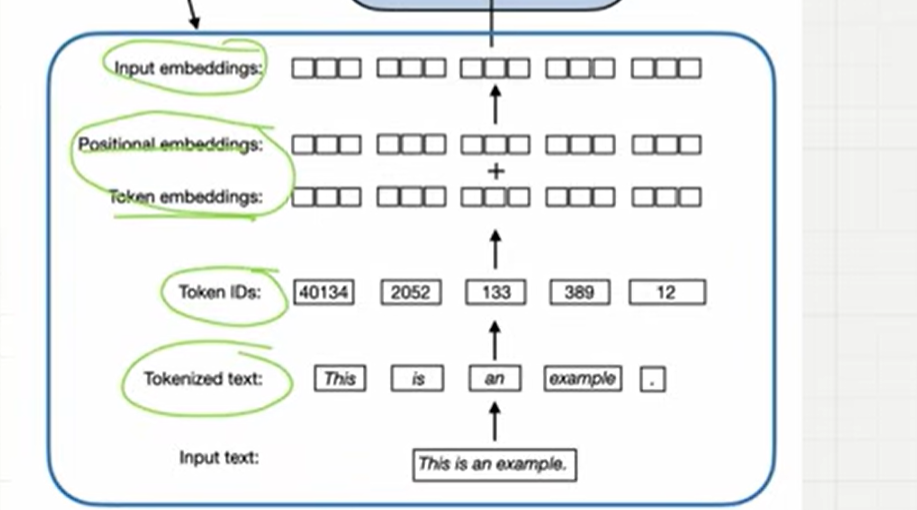